# ML-Guided FeCoCrMnCu LDH OER Catalyst Design
### 機器學習引導高熵層狀雙氫氧化物析氧催化劑設計

本 Notebook 復現論文《**Machine Learning-Guided Design of High-Entropy FeCoCrMnCu Layered Double Hydroxides for Efficient Oxygen Evolution in Alkaline Media**》（ACS Catalysis, DOI: 10.1021/acscatal.5c07303）中的所有機器學習模型訓練程式碼與圖形結果。

## 學習目標
- 掌握高熵材料組成-性質數據集的建立方式
- 實作多項式特徵工程（2\~5 階交互特徵）
- 訓練 XGBoost 回歸模型並進行超參數優化
- 進行 SHAP 可解釋性分析
- 利用模型對 10,626 種可能組成空間進行搜尋，識別最佳催化劑配方

## 復現圖表列表
| 圖號 | 說明 |
|------|------|
| Figure S1 | 五種元素分佈直方圖 |
| Figure S3 | 過電位分佈直方圖 |
| Figure 3  | Pearson 相關係數熱圖（Top 10 特徵） |
| Figure 4  | 特徵重要性長條圖（Gain metric） |
| Figure 5  | 預測值 vs 實際值散點圖 |
| Figure S4 | 殘差圖 |
| Figure S5 | 預測誤差分佈圖 |
| Figure S6 | 預測值箱型圖 |
| Figure 6  | SHAP 蜂群圖（Top 20 特徵） |
| Figure S7 | 平均絕對 SHAP 值長條圖 |
| Figure S8 | 所有可能組成的預測過電位分佈圖 |
| Figure 7  | 與文獻催化劑性能比較 |
| Figure 15 | 傳統方法 vs ML 方法效率比較 |

> **注意**：Figure 8\~14（XRD、SEM、TEM、XPS、BET、ICP-OES、LSV）為實驗表徵結果，無法以計算方式復現。

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'paper1_FeCoCrMnCu_ML_OER'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

if IN_COLAB:
    try:
        os.remove('/content/ChemE-3590')
    except FileNotFoundError:
        pass
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3590')
    os.symlink(source_path, '/content/ChemE-3590')
    NOTEBOOK_DIR = Path('/content/ChemE-3590') / 'extra_examples' / 'paper1'
else:
    NOTEBOOK_DIR = Path.cwd()

OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
FIG_DIR    = OUTPUT_DIR / 'figs'
MODEL_DIR  = OUTPUT_DIR / 'models'

for d in [OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook 工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄:       {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄:       {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook 工作目錄: d:\MyGit\ChemE-3590\extra_examples\paper1
✓ 結果輸出目錄:       d:\MyGit\ChemE-3590\extra_examples\paper1\outputs\paper1_FeCoCrMnCu_ML_OER
✓ 圖檔輸出目錄:       d:\MyGit\ChemE-3590\extra_examples\paper1\outputs\paper1_FeCoCrMnCu_ML_OER\figs


---
### 1. 載入套件

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations, product
from scipy.stats import norm

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

import xgboost as xgb
import shap

# ── 繪圖全局設定 ──────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✓ 所有套件載入完成")

✓ 所有套件載入完成


---
### 2. 實驗數據集（Table S1）

論文使用 70 種不同 FeCoCrMnCu LDHs 組成作為訓練數據集，每個樣品的五種元素摩爾分率總和為 1.0，目標變量為在 $10\ \mathrm{mA\ cm^{-2}}$ 下測得的 OER 過電位（mV）。

In [3]:
# ── Table S1：70 種 FeCoCrMnCu LDHs 實驗數據集 ────────────────────────────────
raw_data = {
    'Fe': [0.10, 0.50, 0.00, 0.00, 0.20, 0.50, 0.50, 0.10, 0.10, 0.35,
           0.00, 0.10, 0.00, 0.00, 1.00, 0.10, 0.00, 0.00, 0.50, 0.00,
           0.20, 0.70, 0.00, 0.00, 0.00, 0.10, 0.00, 0.20, 0.20, 0.10,
           0.30, 0.10, 0.40, 0.50, 0.00, 0.00, 0.00, 0.30, 0.40, 0.20,
           0.60, 0.30, 0.10, 0.00, 0.50, 0.00, 0.40, 0.20, 0.30, 0.00,
           0.00, 0.10, 0.00, 0.00, 0.40, 0.00, 0.20, 0.20, 0.00, 0.00,
           0.10, 0.10, 0.10, 0.60, 0.10, 0.10, 0.10, 0.10, 0.35, 0.35],
    'Co': [0.10, 0.50, 1.00, 0.00, 0.00, 0.00, 0.00, 0.10, 0.20, 0.10,
           0.00, 0.10, 0.25, 0.00, 0.00, 0.60, 0.50, 0.00, 0.00, 0.00,
           0.40, 0.20, 0.00, 0.50, 0.50, 0.10, 0.50, 0.00, 0.10, 0.20,
           0.10, 0.40, 0.30, 0.20, 0.00, 0.70, 0.40, 0.20, 0.20, 0.10,
           0.10, 0.10, 0.40, 0.00, 0.00, 0.00, 0.00, 0.00, 0.40, 0.20,
           0.10, 0.10, 0.00, 0.20, 0.00, 0.40, 0.30, 0.70, 0.00, 0.30,
           0.10, 0.10, 0.60, 0.10, 0.35, 0.35, 0.10, 0.35, 0.10, 0.35],
    'Cr': [0.60, 0.00, 0.00, 0.00, 0.50, 0.50, 0.00, 0.10, 0.10, 0.10,
           0.50, 0.10, 0.25, 0.00, 0.00, 0.10, 0.00, 0.50, 0.00, 0.00,
           0.10, 0.10, 1.00, 0.00, 0.50, 0.00, 0.10, 0.30, 0.10, 0.70,
           0.30, 0.30, 0.00, 0.10, 0.10, 0.10, 0.10, 0.40, 0.10, 0.50,
           0.00, 0.00, 0.50, 0.80, 0.30, 0.30, 0.10, 0.10, 0.20, 0.20,
           0.60, 0.00, 0.40, 0.50, 0.10, 0.00, 0.10, 0.00, 0.10, 0.10,
           0.10, 0.10, 0.10, 0.10, 0.35, 0.10, 0.10, 0.10, 0.10, 0.10],
    'Mn': [0.10, 0.00, 0.00, 1.00, 0.10, 0.00, 0.00, 0.70, 0.40, 0.10,
           0.50, 0.10, 0.25, 0.50, 0.00, 0.10, 0.00, 0.00, 0.50, 0.00,
           0.00, 0.00, 0.00, 0.50, 0.00, 0.20, 0.40, 0.40, 0.60, 0.00,
           0.00, 0.20, 0.10, 0.20, 0.80, 0.20, 0.00, 0.00, 0.00, 0.20,
           0.00, 0.20, 0.00, 0.00, 0.10, 0.50, 0.10, 0.40, 0.00, 0.10,
           0.30, 0.60, 0.10, 0.10, 0.40, 0.20, 0.40, 0.00, 0.40, 0.60,
           0.10, 0.60, 0.10, 0.10, 0.10, 0.10, 0.35, 0.35, 0.35, 0.10],
    'Cu': [0.10, 0.00, 0.00, 0.00, 0.20, 0.00, 0.50, 0.00, 0.20, 0.35,
           0.00, 0.60, 0.25, 0.50, 0.00, 0.10, 0.50, 0.50, 0.00, 1.00,
           0.30, 0.00, 0.00, 0.00, 0.00, 0.60, 0.00, 0.10, 0.00, 0.00,
           0.30, 0.00, 0.20, 0.00, 0.10, 0.00, 0.50, 0.10, 0.30, 0.00,
           0.30, 0.40, 0.00, 0.20, 0.10, 0.20, 0.40, 0.30, 0.10, 0.50,
           0.00, 0.20, 0.50, 0.20, 0.10, 0.40, 0.00, 0.10, 0.50, 0.00,
           0.60, 0.10, 0.10, 0.10, 0.10, 0.35, 0.35, 0.10, 0.10, 0.10],
    'Overpotential': [
        301, 365, 370, 379, 311, 368, 379, 335, 303, 340,
        366, 335, 364, 394, 408, 353.5, 390, 380, 378, 396,
        341, 348, 364, 388, 365, 361, 365, 294, 335, 307,
        305, 331, 344, 335, 383, 369, 383, 286, 335, 313,
        369, 333, 304, 362, 317, 376, 343, 338, 309, 377,
        365, 303, 381, 364, 321, 387, 332, 338, 390, 356,
        311, 324, 355, 349, 312, 367, 345, 357, 340, 353
    ]
}

df = pd.DataFrame(raw_data)
BASE_FEATURES = sorted(['Fe', 'Co', 'Cr', 'Mn', 'Cu'])  # alphabetical: Co Cr Cu Fe Mn

# 驗證：每列摩爾分率總和應為 1
sums = df[BASE_FEATURES].sum(axis=1)
print(f"✓ 數據集形狀: {df.shape}")
print(f"✓ 摩爾分率總和檢查 - Min: {sums.min():.4f}, Max: {sums.max():.4f}")
print(f"✓ 過電位範圍: {df['Overpotential'].min():.1f} ~ {df['Overpotential'].max():.1f} mV")
print(f"✓ 過電位均值: {df['Overpotential'].mean():.1f} mV，標準差: {df['Overpotential'].std():.1f} mV")
df.head(5)

✓ 數據集形狀: (70, 6)
✓ 摩爾分率總和檢查 - Min: 1.0000, Max: 1.0000
✓ 過電位範圍: 286.0 ~ 408.0 mV
✓ 過電位均值: 349.2 mV，標準差: 29.0 mV


,Fe,Co,Cr,Mn,Cu,Overpotential
0,0.1,0.1,0.6,0.1,0.1,301.0
1,0.5,0.5,0.0,0.0,0.0,365.0
2,0.0,1.0,0.0,0.0,0.0,370.0
3,0.0,0.0,0.0,1.0,0.0,379.0
4,0.2,0.0,0.5,0.1,0.2,311.0


---
### 3. 資料探索分析（Figure S1 & Figure S3）

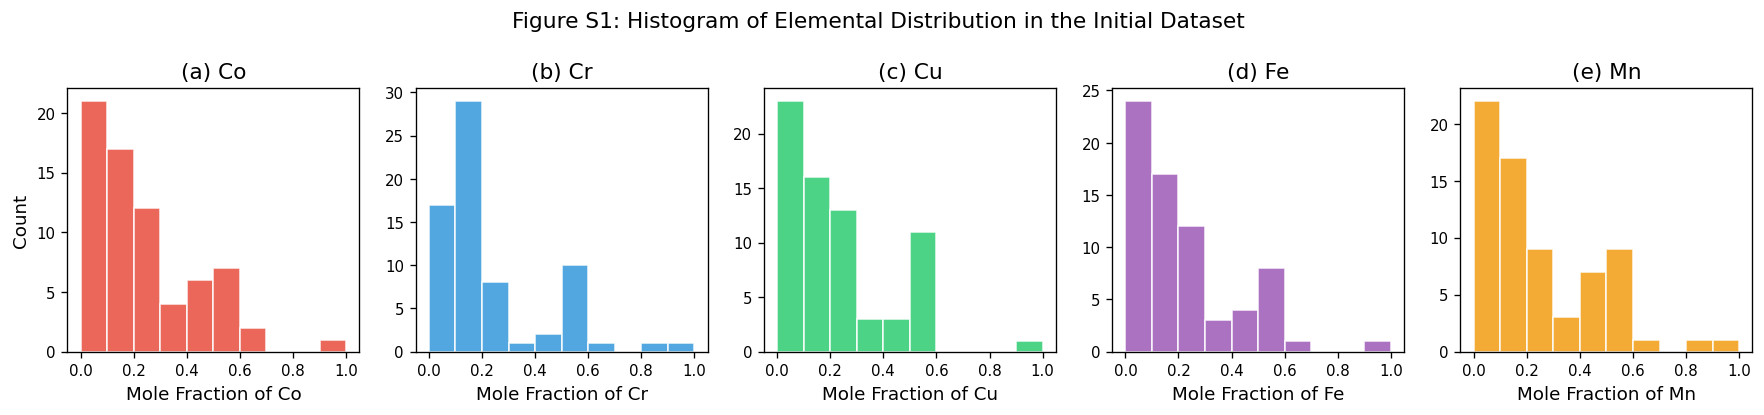

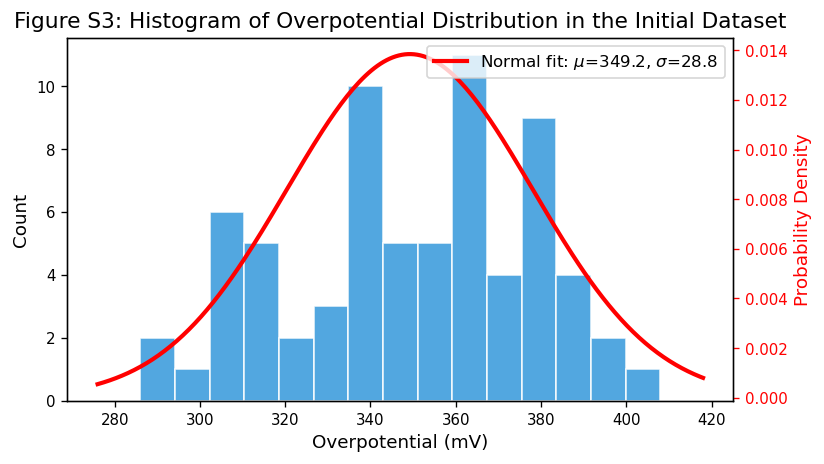

In [4]:
# ── Figure S1：五種元素摩爾分率分佈直方圖 ────────────────────────────────────
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12']
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5), sharey=False)
fig.suptitle('Figure S1: Histogram of Elemental Distribution in the Initial Dataset', fontsize=13)

for ax, feat, color in zip(axes, BASE_FEATURES, colors):
    ax.hist(df[feat], bins=10, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel(f'Mole Fraction of {feat}')
    ax.set_ylabel('Count' if feat == BASE_FEATURES[0] else '')
    ax.set_title(f'({chr(97 + BASE_FEATURES.index(feat))}) {feat}')

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS1_element_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure S3：過電位分佈直方圖 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
n, bins, patches = ax.hist(df['Overpotential'], bins=15, color='#3498DB',
                            edgecolor='white', alpha=0.85, density=False)
# Fit normal distribution
mu, std = norm.fit(df['Overpotential'])
x_fit = np.linspace(df['Overpotential'].min() - 10, df['Overpotential'].max() + 10, 200)
ax2 = ax.twinx()
ax2.plot(x_fit, norm.pdf(x_fit, mu, std), 'r-', lw=2.5,
         label=f'Normal fit: $\\mu$={mu:.1f}, $\\sigma$={std:.1f}')
ax2.set_ylabel('Probability Density', color='red')
ax2.tick_params(axis='y', colors='red')
ax.set_xlabel('Overpotential (mV)')
ax.set_ylabel('Count')
ax.set_title('Figure S3: Histogram of Overpotential Distribution in the Initial Dataset')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS3_overpotential_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

---
### 4. 特徵工程（多項式交互特徵展開）

為捕捉元素間的非線性相互作用，從原始 5 個組成特徵展開為高階特徵：

**展開映射** $\Phi(X)$：

$$
\Phi(X) = [\mathrm{Co},\ \mathrm{Cr},\ \mathrm{Cu},\ \mathrm{Fe},\ \mathrm{Mn},\ \mathrm{Co*Cr},\ \mathrm{Co*Cu},\ \ldots,\ \mathrm{Co*Cr*Cu*Fe*Mn},\ \ldots,\ \mathrm{Mn}^5]
$$

生成的特徵類型：
- **交互項（2\~5 階）**：使用 `combinations` 生成不重複組合，共 $C_5^2 + C_5^3 + C_5^4 + C_5^5 = 26$ 項
- **冪次項（2\~5 次方）**：每個元素的 2\~5 次方，共 $5 \times 4 = 20$ 項
- **原始特徵（1 階）**：5 項

**總計**：$5 + 26 + 20 = 51$ 個特徵，再由 SelectKBest 選出前 $K=25$ 個。

In [5]:
def generate_interactions(df_input, features, max_order=5):
    """
    生成多項式交互特徵（cross-interaction terms + power terms）。
    特徵名稱按字母順序排列，以 '*' 連接（與論文一致）。
    """
    features_sorted = sorted(features)
    result = df_input[features_sorted].copy()

    # 交互項（2 到 max_order 階，無重複組合）
    for order in range(2, max_order + 1):
        for combo in combinations(features_sorted, order):
            name = '*'.join(combo)
            result[name] = df_input[list(combo)].prod(axis=1)

    # 冪次項（每個特徵的 2 次方到 max_order 次方）
    for feat in features_sorted:
        for power in range(2, max_order + 1):
            result[f'{feat}^{power}'] = df_input[feat] ** power

    return result


# 對完整數據集生成特徵
X_all = generate_interactions(df, BASE_FEATURES, max_order=5)
y     = df['Overpotential']
feature_names = list(X_all.columns)

print(f"✓ 原始特徵數: {len(BASE_FEATURES)}")
print(f"✓ 展開後特徵總數: {X_all.shape[1]}（理論值: 5 + 26 + 20 = 51）")
print(f"\n前 10 個特徵名稱範例：")
print(feature_names[:10])

✓ 原始特徵數: 5
✓ 展開後特徵總數: 51（理論值: 5 + 26 + 20 = 51）

前 10 個特徵名稱範例：
['Co', 'Cr', 'Cu', 'Fe', 'Mn', 'Co*Cr', 'Co*Cu', 'Co*Fe', 'Co*Mn', 'Cr*Cu']


---
### 5. Pearson 相關性分析（Figure 3）

Pearson 相關係數公式：

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

$r \in [-1,\ 1]$，負值表示與過電位呈負相關（該特徵有利於降低過電位）。

選取與過電位相關性最強的前 9 個特徵，加上過電位本身，共組成 $10 \times 10$ 的下三角相關矩陣熱圖。

Top 9 features by absolute correlation with Overpotential:
   1. Co*Cr*Fe                        r = -0.5412
   2. Cr*Cu*Fe                        r = -0.4932
   3. Cr*Fe*Mn                        r = -0.4906
   4. Cr*Fe                           r = -0.4702
   5. Cr*Cu*Fe*Mn                     r = -0.4052
   6. Co*Cr*Cu*Fe                     r = -0.3888
   7. Cu^2                            r = 0.3129
   8. Cu*Fe*Mn                        r = -0.3119
   9. Co*Cr*Fe*Mn                     r = -0.2821


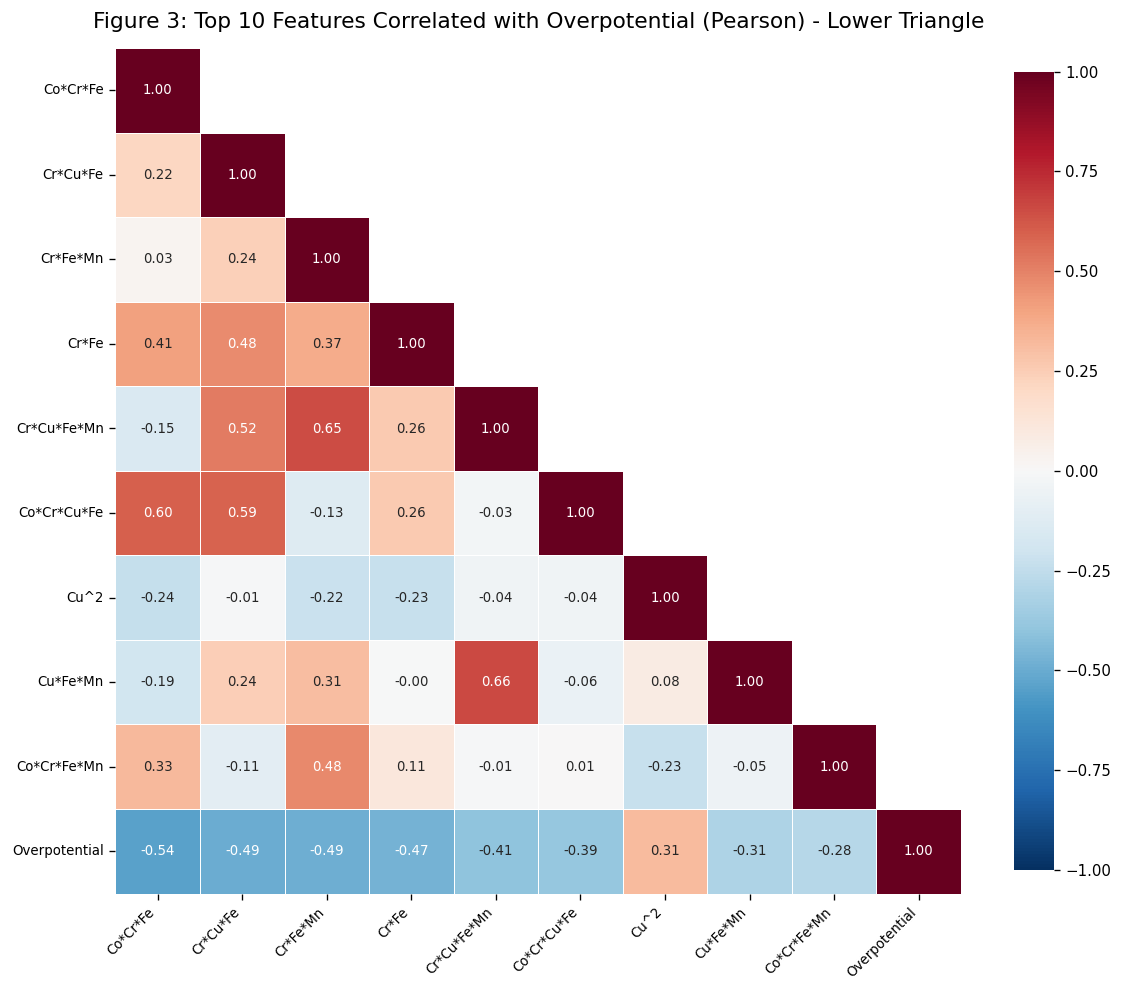

In [6]:
# ── Figure 3：Pearson 相關係數下三角熱圖 ─────────────────────────────────────
all_data = pd.concat([X_all, y.rename('Overpotential')], axis=1)

# 計算所有特徵與過電位的相關係數（取絕對值排序）
corr_with_target = all_data.corr()['Overpotential'].drop('Overpotential')
top9_features    = corr_with_target.abs().nlargest(9).index.tolist()

print("Top 9 features by absolute correlation with Overpotential:")
for i, f in enumerate(top9_features, 1):
    print(f"  {i:2d}. {f:<30s}  r = {corr_with_target[f]:.4f}")

# 建立 10×10 相關矩陣（top-9 特徵 + 過電位）
top10_cols   = top9_features + ['Overpotential']
corr_matrix  = all_data[top10_cols].corr()

# 下三角 mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Figure 3: Top 10 Features Correlated with Overpotential (Pearson) - Lower Triangle',
             pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'Figure3_pearson_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

---
### 6. 訓練/測試集分割與模型訓練（XGBoost Pipeline）

**最佳超參數**（論文 Grid Search 結果）：

| 超參數 | 值 |
|--------|-----|
| `n_estimators` | 1300 |
| `learning_rate` | 0.2 |
| `max_depth` | 1 |
| `min_child_weight` | 5 |
| `subsample` | 0.2 |
| `colsample_bytree` | 0.3 |
| `reg_alpha` (L1) | 0.14 |
| `reg_lambda` (L2) | 0.8 |
| `SelectKBest` K | 25 |

資料分割：80% 訓練集（56 樣本）、20% 測試集（14 樣本）。

In [7]:
# ── 訓練/測試分割（80/20）──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"✓ 訓練集大小: {X_train.shape[0]} 樣本")
print(f"✓ 測試集大小: {X_test.shape[0]} 樣本")

# ── XGBoost Pipeline（Yeo-Johnson 標準化 → SelectKBest → XGBoost）────────────
pipeline = Pipeline([
    ('scaler',   PowerTransformer(method='yeo-johnson')),
    ('selector', SelectKBest(f_regression, k=25)),
    ('model',    xgb.XGBRegressor(
        n_estimators=1300,
        learning_rate=0.2,
        max_depth=1,
        min_child_weight=5,
        subsample=0.2,
        colsample_bytree=0.3,
        reg_alpha=0.14,
        reg_lambda=0.8,
        importance_type='gain',
        random_state=RANDOM_STATE,
        verbosity=0,
        eval_metric='rmse'
    ))
])

pipeline.fit(X_train, y_train)
print("\n✓ Pipeline 訓練完成")

# ── 模型性能評估 ──────────────────────────────────────────────────────────────
y_train_pred = pipeline.predict(X_train)
y_test_pred  = pipeline.predict(X_test)

r2_train   = r2_score(y_train, y_train_pred)
r2_test    = r2_score(y_test,  y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

print(f"\n{'─'*40}")
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print(f"{'─'*40}")
print(f"{'R²':<20} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"{'RMSE (mV)':<20} {rmse_train:>10.2f} {rmse_test:>10.2f}")
print(f"{'─'*40}")
print(f"\n論文目標 → Train R²: 0.967, Test R²: 0.84, Test RMSE: 9.95 mV")

# ── 提取 pipeline 組件（供後續分析用）──────────────────────────────────────────
scaler_fitted           = pipeline.named_steps['scaler']
selector_fitted         = pipeline.named_steps['selector']
model_xgb               = pipeline.named_steps['model']
selected_mask           = selector_fitted.get_support()
selected_feature_names  = np.array(feature_names)[selected_mask]
print(f"\n✓ SelectKBest 選出 {len(selected_feature_names)} 個特徵，前 5 個：")
print(list(selected_feature_names[:5]))

✓ 訓練集大小: 56 樣本
✓ 測試集大小: 14 樣本

✓ Pipeline 訓練完成

────────────────────────────────────────
Metric                    Train       Test
────────────────────────────────────────
R²                       0.9466     0.8588
RMSE (mV)                  6.87       9.34
────────────────────────────────────────

論文目標 → Train R²: 0.967, Test R²: 0.84, Test RMSE: 9.95 mV

✓ SelectKBest 選出 25 個特徵，前 5 個：
[np.str_('Cr'), np.str_('Fe'), np.str_('Co*Cr'), np.str_('Co*Fe'), np.str_('Cr*Fe')]


---
### 7. 特徵重要性（Figure 4）與預測對比散點圖（Figure 5）

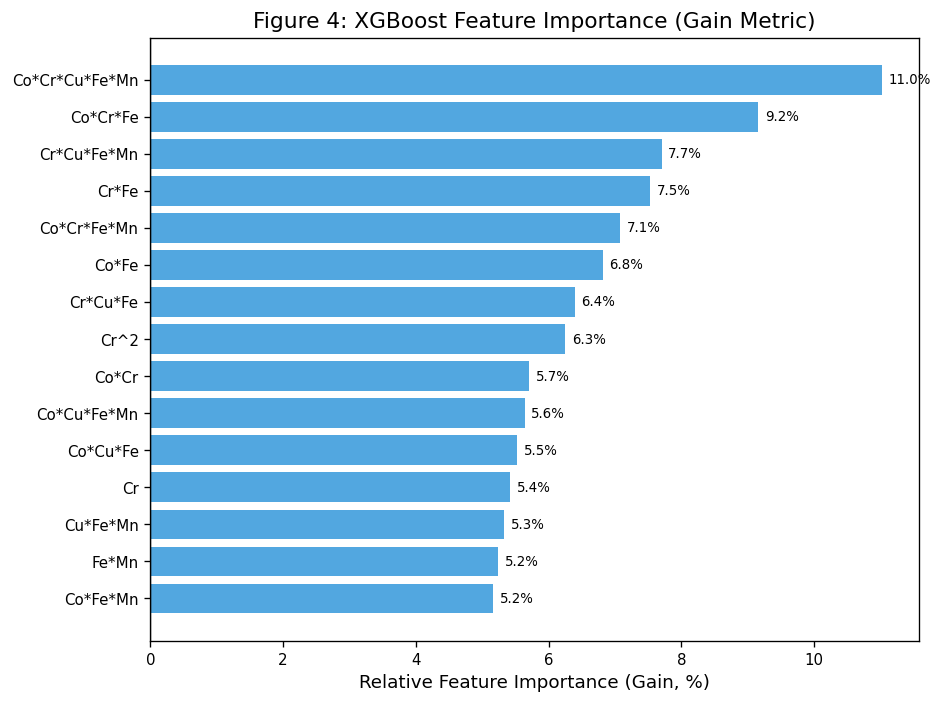

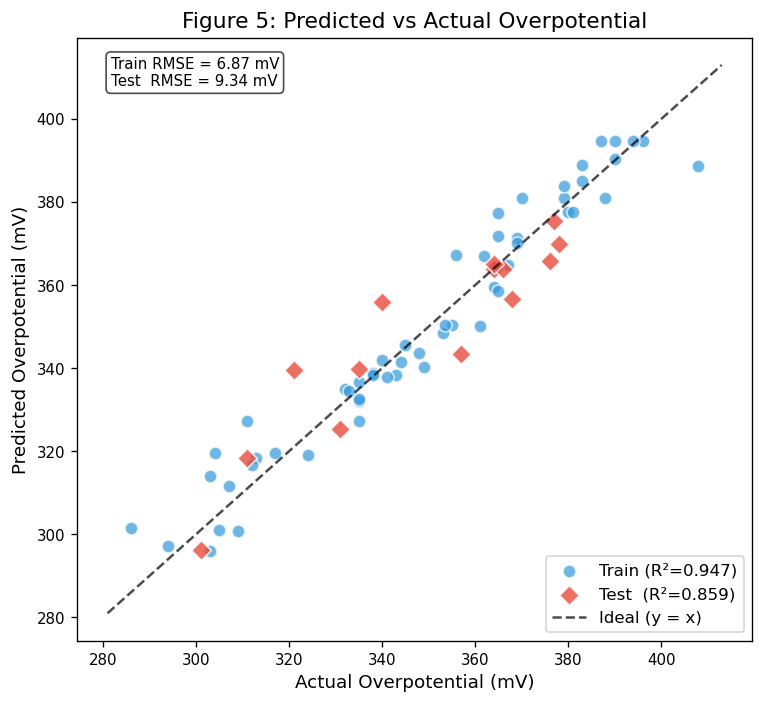

In [8]:
# ── Figure 4：特徵重要性長條圖（Gain metric）────────────────────────────────
booster       = model_xgb.get_booster()
gain_scores   = booster.get_score(importance_type='gain')

# f0, f1, ... 映射到實際特徵名稱
named_gain = {
    selected_feature_names[int(k[1:])]: v
    for k, v in gain_scores.items()
}
imp_df = (pd.DataFrame.from_dict(named_gain, orient='index', columns=['Gain'])
            .sort_values('Gain', ascending=True).tail(15))

# 歸一化為百分比
imp_df['Gain_pct'] = imp_df['Gain'] / imp_df['Gain'].sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(imp_df.index, imp_df['Gain_pct'], color='#3498DB', alpha=0.85)
ax.set_xlabel('Relative Feature Importance (Gain, %)')
ax.set_title('Figure 4: XGBoost Feature Importance (Gain Metric)')
ax.axvline(x=0, color='black', lw=0.8)
for bar, val in zip(bars, imp_df['Gain_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'Figure4_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 5：預測值 vs 實際值散點圖 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_train, y_train_pred, c='#3498DB', alpha=0.7, s=60, label=f'Train (R²={r2_train:.3f})', edgecolors='white')
ax.scatter(y_test,  y_test_pred,  c='#E74C3C', alpha=0.8, s=70, marker='D', label=f'Test  (R²={r2_test:.3f})', edgecolors='white')
# 1:1 reference line
lims = [min(y.min(), y_train_pred.min(), y_test_pred.min()) - 5,
        max(y.max(), y_train_pred.max(), y_test_pred.max()) + 5]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.7, label='Ideal (y = x)')
ax.set_xlabel('Actual Overpotential (mV)')
ax.set_ylabel('Predicted Overpotential (mV)')
ax.set_title('Figure 5: Predicted vs Actual Overpotential')
ax.legend()
ax.text(0.05, 0.92, f'Train RMSE = {rmse_train:.2f} mV\nTest  RMSE = {rmse_test:.2f} mV',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'Figure5_predicted_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()

---
### 8. 5-Fold 交叉驗證與診斷圖（Figure S4、S5、S6）

評估指標：

$$
\mathrm{RMSE} = \sqrt{\frac{1}{m}\sum_{i=1}^{m}\left(\hat{\eta}_i - \eta_i\right)^2}, \qquad
R^2 = 1 - \frac{\sum_{i=1}^{m}(\hat{\eta}_i - \eta_i)^2}{\sum_{i=1}^{m}(\bar{\eta} - \eta_i)^2}
$$

5-Fold CV on Training Set:
  R²   = 0.7566   （論文: 0.83）
  RMSE = 14.67 mV  （論文: 10.77 mV）


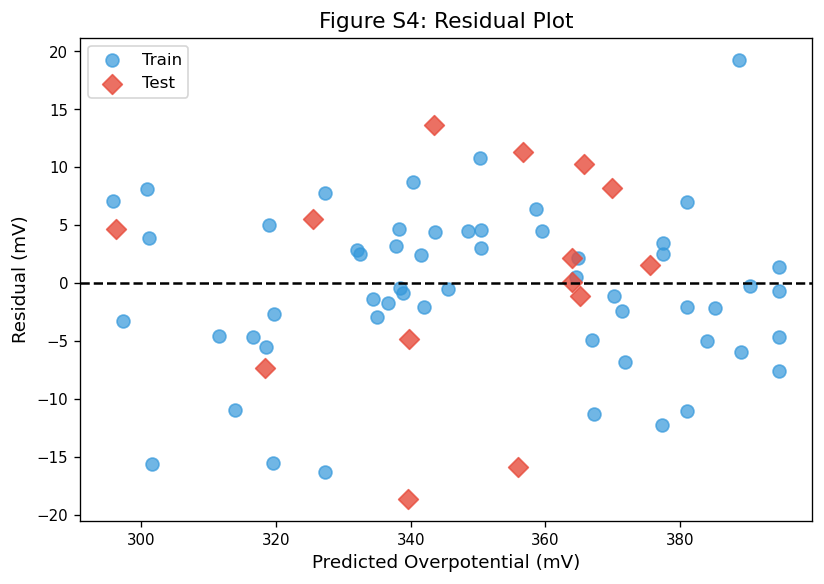

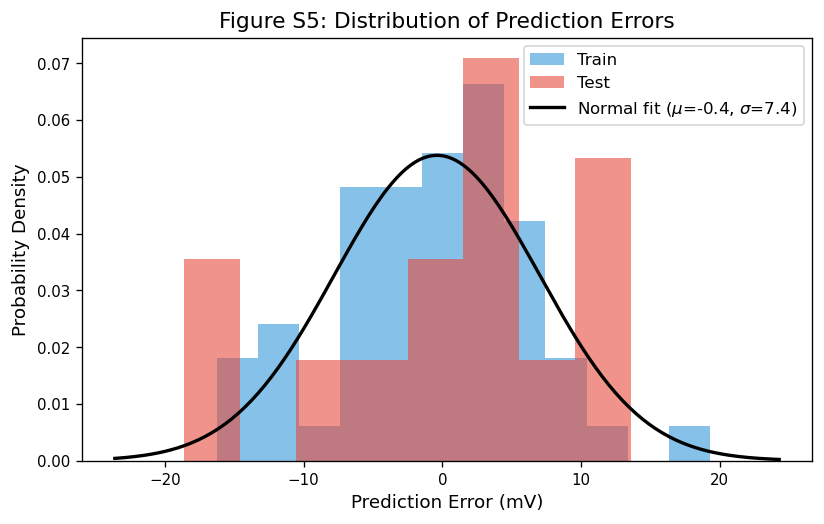

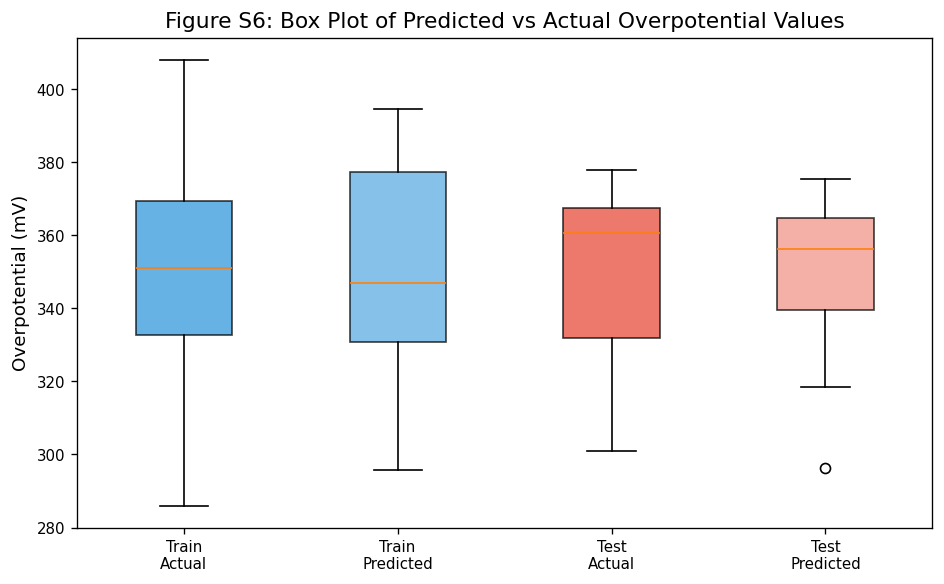

In [9]:
# ── 5-Fold 交叉驗證（在訓練集上）───────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pred_train = cross_val_predict(pipeline, X_train, y_train, cv=kf)

cv_r2   = r2_score(y_train, cv_pred_train)
cv_rmse = np.sqrt(mean_squared_error(y_train, cv_pred_train))
print(f"5-Fold CV on Training Set:")
print(f"  R²   = {cv_r2:.4f}   （論文: 0.83）")
print(f"  RMSE = {cv_rmse:.2f} mV  （論文: 10.77 mV）")

# 全資料預測（用於殘差圖）
y_all_pred  = pipeline.predict(X_all)
residuals   = np.array(y) - y_all_pred

train_idx  = y_train.index
test_idx   = y_test.index
res_train  = y_train.values - y_train_pred
res_test   = y_test.values  - y_test_pred

# ── Figure S4：殘差圖 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_train_pred, res_train, c='#3498DB', alpha=0.7, s=60, label='Train')
ax.scatter(y_test_pred,  res_test,  c='#E74C3C', alpha=0.8, s=70, marker='D', label='Test')
ax.axhline(y=0, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Overpotential (mV)')
ax.set_ylabel('Residual (mV)')
ax.set_title('Figure S4: Residual Plot')
ax.legend()
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS4_residual_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure S5：預測誤差分佈圖 ────────────────────────────────────────────────
all_res = np.concatenate([res_train, res_test])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(res_train, bins=12, alpha=0.6, color='#3498DB', label='Train', density=True)
ax.hist(res_test,  bins=8,  alpha=0.6, color='#E74C3C', label='Test',  density=True)
# 正態分佈擬合（全部殘差）
mu_r, std_r = norm.fit(all_res)
x_r = np.linspace(all_res.min()-5, all_res.max()+5, 200)
ax.plot(x_r, norm.pdf(x_r, mu_r, std_r), 'k-', lw=2,
        label=f'Normal fit ($\\mu$={mu_r:.1f}, $\\sigma$={std_r:.1f})')
ax.set_xlabel('Prediction Error (mV)')
ax.set_ylabel('Probability Density')
ax.set_title('Figure S5: Distribution of Prediction Errors')
ax.legend()
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS5_error_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure S6：預測值箱型圖 ──────────────────────────────────────────────────
box_data   = [y_train.values, y_train_pred, y_test.values, y_test_pred]
box_labels = ['Train\nActual', 'Train\nPredicted', 'Test\nActual', 'Test\nPredicted']
colors_box = ['#3498DB', '#5DADE2', '#E74C3C', '#F1948A']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_ylabel('Overpotential (mV)')
ax.set_title('Figure S6: Box Plot of Predicted vs Actual Overpotential Values')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS6_box_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

---
### 9. SHAP 可解釋性分析（Figure 6 & Figure S7）

**SHAP（Shapley Additive exPlanations）** 基於合作博弈論，量化每個特徵對最終預測輸出的邊際貢獻。

- **Figure 6（蜂群圖）**：展示每個特徵的 SHAP 值分佈及方向效應。紅色 = 特徵值高；藍色 = 特徵值低。
- **Figure S7（長條圖）**：展示各特徵的平均絕對 SHAP 值（整體影響力）。

> **Gain vs SHAP 的差別**：Gain 反映模型訓練中特徵的使用頻率（結構層面）；SHAP 反映特徵對最終預測輸出的實際邊際貢獻（預測層面）。

✓ SHAP 計算完成，shap_values shape: (56, 25)


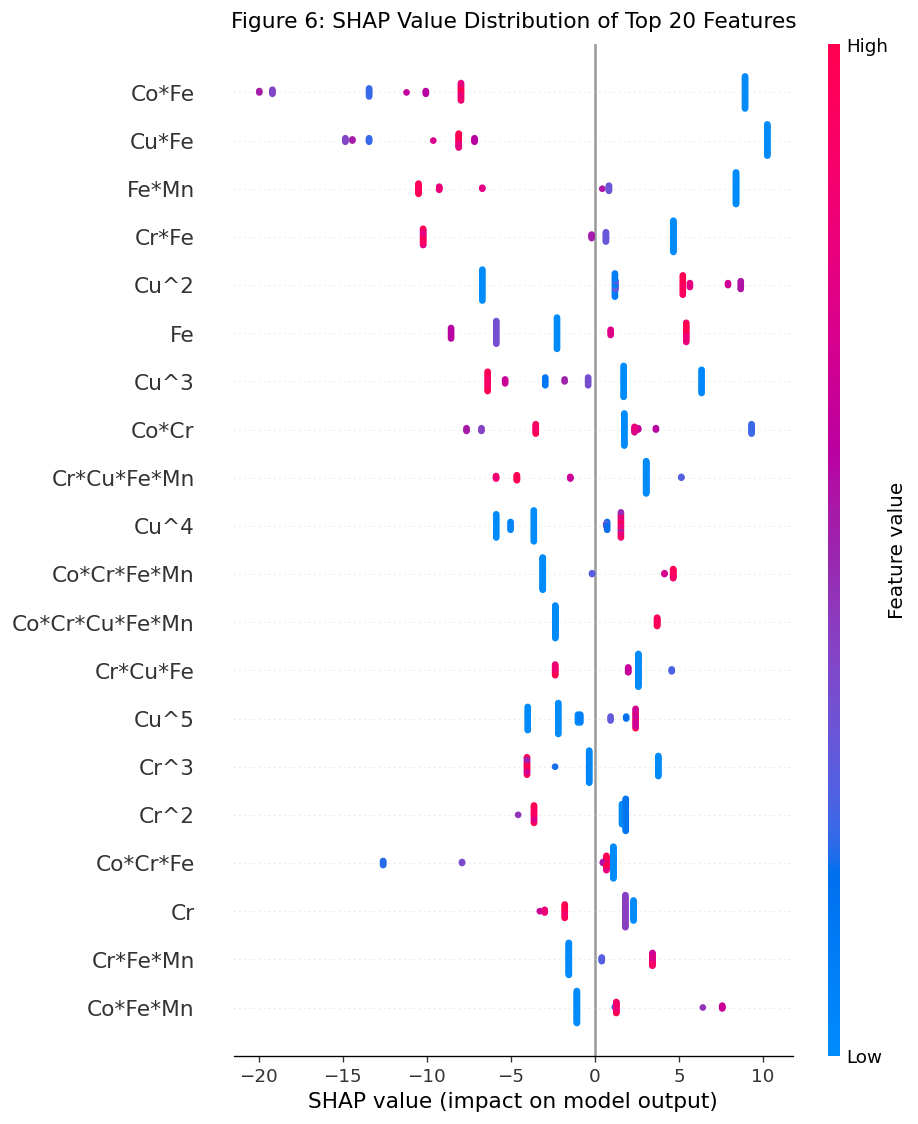

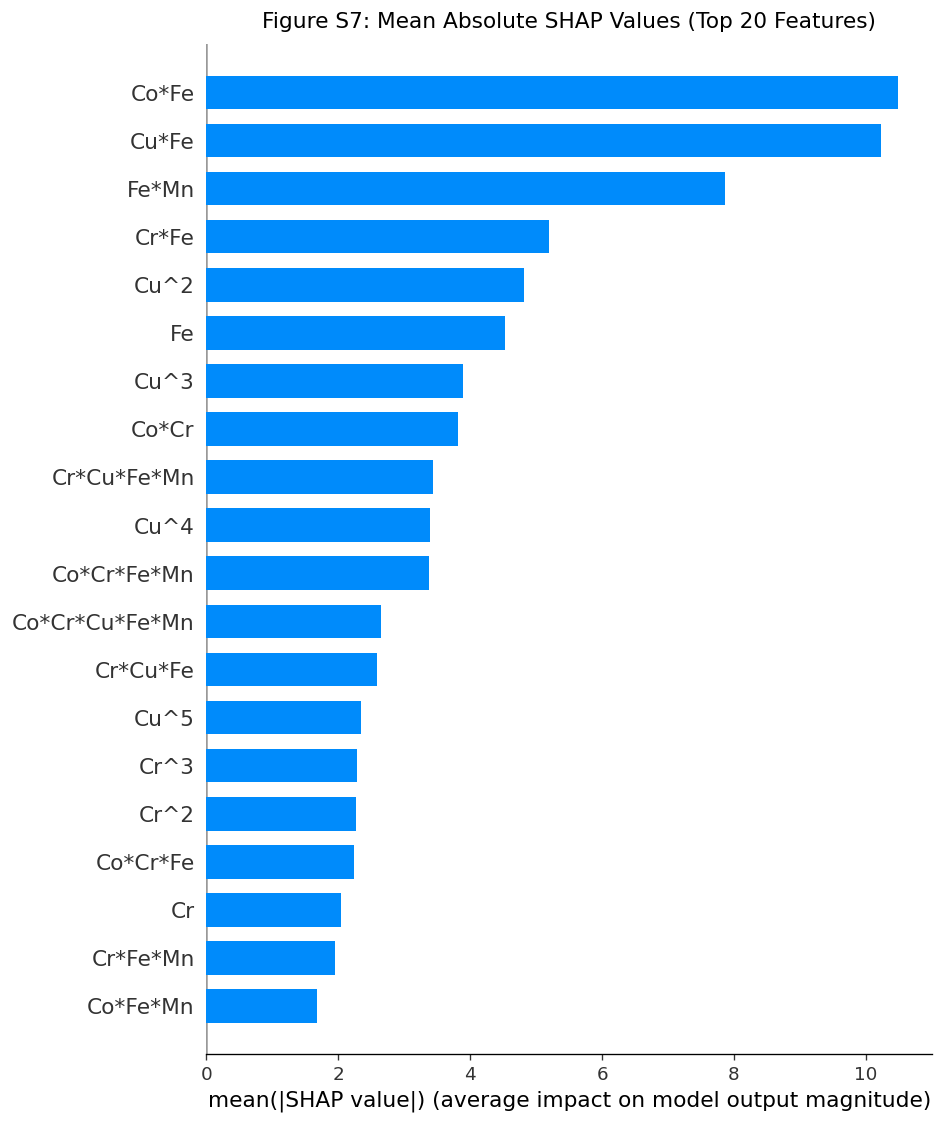


Top 10 Features by Mean |SHAP|:
    Feature  Mean |SHAP|
      Co*Fe    10.485013
      Cu*Fe    10.231790
      Fe*Mn     7.860054
      Cr*Fe     5.193962
       Cu^2     4.809330
         Fe     4.534464
       Cu^3     3.897433
      Co*Cr     3.820053
Cr*Cu*Fe*Mn     3.443310
       Cu^4     3.391199


In [10]:
# ── 準備 SHAP 輸入資料（對訓練集進行前處理）─────────────────────────────────
X_train_scaled    = scaler_fitted.transform(X_train)
X_train_selected  = selector_fitted.transform(X_train_scaled)

explainer         = shap.TreeExplainer(model_xgb)
shap_values       = explainer.shap_values(X_train_selected)  # shape: (n_train, 25)

print(f"✓ SHAP 計算完成，shap_values shape: {shap_values.shape}")

# ── Figure 6：SHAP 蜂群圖（Top 20 特徵）─────────────────────────────────────
shap.summary_plot(
    shap_values, X_train_selected,
    feature_names=selected_feature_names.tolist(),
    max_display=20,
    show=False
)
plt.title('Figure 6: SHAP Value Distribution of Top 20 Features', pad=10)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'Figure6_SHAP_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Figure S7：平均絕對 SHAP 值長條圖 ────────────────────────────────────────
shap.summary_plot(
    shap_values, X_train_selected,
    feature_names=selected_feature_names.tolist(),
    max_display=20,
    plot_type='bar',
    show=False
)
plt.title('Figure S7: Mean Absolute SHAP Values (Top 20 Features)', pad=10)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS7_SHAP_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── 列印 Top 10 SHAP 重要特徵 ─────────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)
print("\nTop 10 Features by Mean |SHAP|:")
print(shap_df.head(10).to_string(index=False))

---
### 10. 最佳組成搜尋（Figure S8）

對所有可能的 Fe/Co/Cr/Mn/Cu 摩爾比組合（0.05 步長，總和 = 1.0）進行窮舉預測，共 $C_{24}^4 = \mathbf{10{,}626}$ 種組成，識別過電位最低的最佳配方。

> 論文中加入特徵範圍約束（限制在訓練集的 min-max 範圍內），確保預測點在插值範圍內，避免外插不可靠性。

Total compositions generated: 10626 (expected: 10626)
Compositions after domain constraint: 10626

Best composition found by model:
Fe                              0.100000
Co                              0.050000
Cr                              0.600000
Mn                              0.050000
Cu                              0.200000
Predicted_Overpotential_mV    260.831116
Name: 3652, dtype: float64


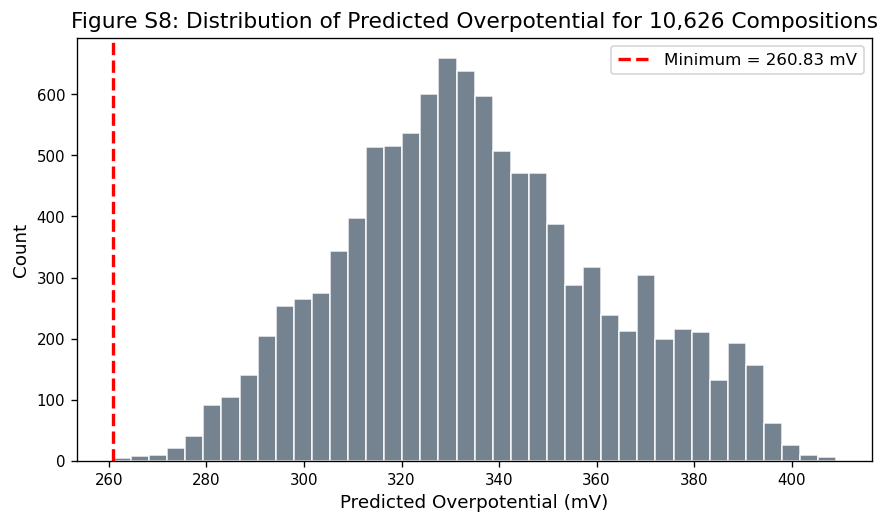


Additional validation set (Table S2 style):


,Fe,Co,Cr,Mn,Cu,Experimental,Predicted,Error_percent
0,0.20,0.20,0.20,0.20,0.20,307.07,280.894043,8.524427
1,0.50,0.00,0.10,0.15,0.25,345.01,328.459412,4.797133
2,0.75,0.15,0.05,0.05,0.00,365.20,342.521027,6.210015


In [11]:
# ── 用全資料重訓模型（用於最終組成搜尋）──────────────────────────────────────
pipeline_full = Pipeline([
    ('scaler',   PowerTransformer(method='yeo-johnson')),
    ('selector', SelectKBest(f_regression, k=25)),
    ('model',    xgb.XGBRegressor(
        n_estimators=1300,
        learning_rate=0.2,
        max_depth=1,
        min_child_weight=5,
        subsample=0.2,
        colsample_bytree=0.3,
        reg_alpha=0.14,
        reg_lambda=0.8,
        importance_type='gain',
        random_state=RANDOM_STATE,
        verbosity=0,
        eval_metric='rmse'
    ))
])
pipeline_full.fit(X_all, y)

# ── 生成所有 0.05 步長且總和為 1.0 的組成（理論值 C(24,4)=10,626）────────────
compositions = []
for fe_i in range(21):
    for co_i in range(21 - fe_i):
        for cr_i in range(21 - fe_i - co_i):
            for mn_i in range(21 - fe_i - co_i - cr_i):
                cu_i = 20 - fe_i - co_i - cr_i - mn_i
                compositions.append({
                    'Fe': fe_i / 20,
                    'Co': co_i / 20,
                    'Cr': cr_i / 20,
                    'Mn': mn_i / 20,
                    'Cu': cu_i / 20,
                })

virtual_df = pd.DataFrame(compositions)
print(f"Total compositions generated: {len(virtual_df)} (expected: 10626)")

# ── 特徵範圍約束（限制在訓練數據的插值範圍）──────────────────────────────────
feature_min = df[BASE_FEATURES].min()
feature_max = df[BASE_FEATURES].max()

mask_domain = np.ones(len(virtual_df), dtype=bool)
for feat in BASE_FEATURES:
    mask_domain &= (virtual_df[feat] >= feature_min[feat]) & (virtual_df[feat] <= feature_max[feat])

virtual_df = virtual_df[mask_domain].reset_index(drop=True)
print(f"Compositions after domain constraint: {len(virtual_df)}")

# ── 預測所有候選組成的過電位 ──────────────────────────────────────────────────
X_virtual = generate_interactions(virtual_df, BASE_FEATURES, max_order=5)
virtual_pred = pipeline_full.predict(X_virtual)

virtual_df['Predicted_Overpotential_mV'] = virtual_pred
best_idx = virtual_df['Predicted_Overpotential_mV'].idxmin()
best_row = virtual_df.loc[best_idx]

print("\nBest composition found by model:")
print(best_row[['Fe', 'Co', 'Cr', 'Mn', 'Cu', 'Predicted_Overpotential_mV']])

# ── Figure S8：預測過電位分佈圖 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(virtual_df['Predicted_Overpotential_mV'], bins=40,
        color='#5D6D7E', alpha=0.85, edgecolor='white')
ax.axvline(best_row['Predicted_Overpotential_mV'], color='red', linestyle='--', linewidth=2,
           label=f"Minimum = {best_row['Predicted_Overpotential_mV']:.2f} mV")
ax.set_xlabel('Predicted Overpotential (mV)')
ax.set_ylabel('Count')
ax.set_title('Figure S8: Distribution of Predicted Overpotential for 10,626 Compositions')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'FigureS8_predicted_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Table S2：額外 3 組獨立驗證樣本（論文補充資料）────────────────────────────
extra_samples = pd.DataFrame([
    {'Fe': 0.20, 'Co': 0.20, 'Cr': 0.20, 'Mn': 0.20, 'Cu': 0.20, 'Experimental': 307.07},
    {'Fe': 0.50, 'Co': 0.00, 'Cr': 0.10, 'Mn': 0.15, 'Cu': 0.25, 'Experimental': 345.01},
    {'Fe': 0.75, 'Co': 0.15, 'Cr': 0.05, 'Mn': 0.05, 'Cu': 0.00, 'Experimental': 365.20},
])

X_extra = generate_interactions(extra_samples[['Fe', 'Co', 'Cr', 'Mn', 'Cu']], BASE_FEATURES, max_order=5)
extra_samples['Predicted'] = pipeline_full.predict(X_extra)
extra_samples['Error_percent'] = (np.abs(extra_samples['Predicted'] - extra_samples['Experimental']) / extra_samples['Experimental']) * 100

print("\nAdditional validation set (Table S2 style):")
display(extra_samples)

---
### 11. Literature Comparison (Figure 7)

This figure compares overpotential at 10 mA cm$^{-2}$ between the ML-optimized catalyst in this study and representative recently reported catalysts.

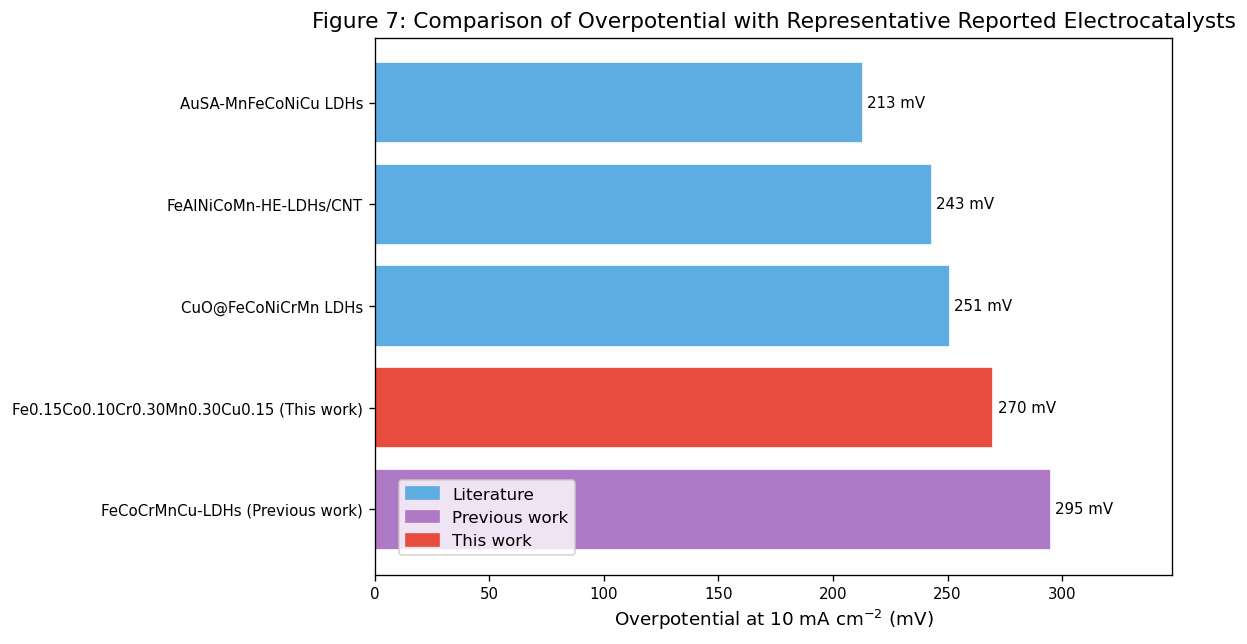

,Catalyst,Overpotential_mV,Category
0,AuSA-MnFeCoNiCu LDHs,213,Literature
1,FeAlNiCoMn-HE-LDHs/CNT,243,Literature
2,CuO@FeCoNiCrMn LDHs,251,Literature
3,Fe0.15Co0.10Cr0.30Mn0.30Cu0.15 (This work),270,This work
4,FeCoCrMnCu-LDHs (Previous work),295,Previous


In [13]:
# ── Figure 7：與近年催化劑過電位比較 ─────────────────────────────────────────
literature_df = pd.DataFrame([
    {'Catalyst': 'AuSA-MnFeCoNiCu LDHs', 'Overpotential_mV': 213, 'Category': 'Literature'},
    {'Catalyst': 'FeAlNiCoMn-HE-LDHs/CNT', 'Overpotential_mV': 243, 'Category': 'Literature'},
    {'Catalyst': 'CuO@FeCoNiCrMn LDHs', 'Overpotential_mV': 251, 'Category': 'Literature'},
    {'Catalyst': 'FeCoCrMnCu-LDHs (Previous work)', 'Overpotential_mV': 295, 'Category': 'Previous'},
    {'Catalyst': 'Fe0.15Co0.10Cr0.30Mn0.30Cu0.15 (This work)', 'Overpotential_mV': 270, 'Category': 'This work'},
])

literature_df = literature_df.sort_values('Overpotential_mV', ascending=True).reset_index(drop=True)

palette = []
for cat in literature_df['Category']:
    if cat == 'This work':
        palette.append('#E74C3C')
    elif cat == 'Previous':
        palette.append('#AF7AC5')
    else:
        palette.append('#5DADE2')

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(literature_df['Catalyst'], literature_df['Overpotential_mV'], color=palette, edgecolor='white')
ax.set_xlabel('Overpotential at 10 mA cm$^{-2}$ (mV)')
ax.set_title('Figure 7: Comparison of Overpotential with Representative Reported Electrocatalysts')
ax.invert_yaxis()

for bar, val in zip(bars, literature_df['Overpotential_mV']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.0f} mV', va='center', fontsize=9)

legend_handles = [
    mpatches.Patch(color='#5DADE2', label='Literature'),
    mpatches.Patch(color='#AF7AC5', label='Previous work'),
    mpatches.Patch(color='#E74C3C', label='This work')
]
ax.legend(handles=legend_handles, loc='lower left', bbox_to_anchor=(0.02, 0.02))
ax.set_xlim(0, max(literature_df['Overpotential_mV']) * 1.18)

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'Figure7_literature_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

display(literature_df)

---
### 12. Efficiency Gain and Final Summary (Figure 15)

The paper highlights that machine learning reduces experimental burden from 10,626 possible combinations to only 70 experimentally measured compositions, corresponding to about 99.3% reduction in time and effort.

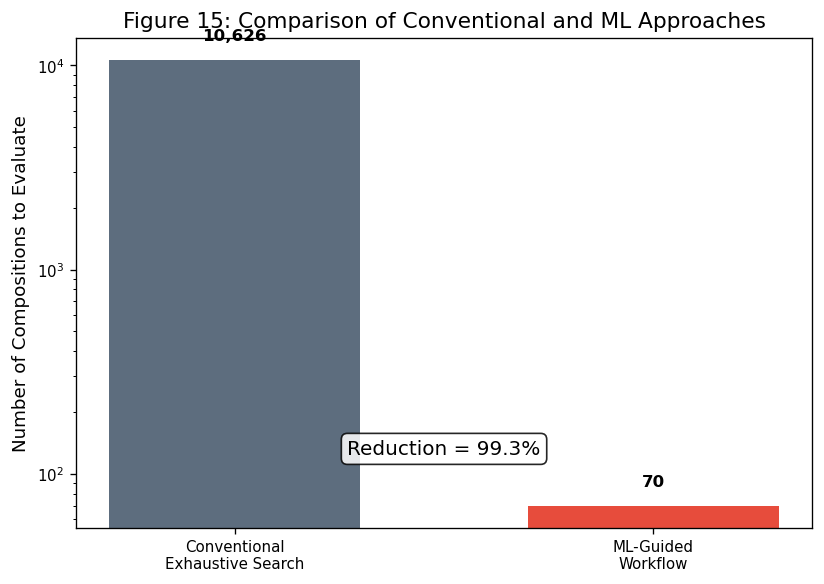

Final key outputs
- Best composition (predicted): Fe0.10 Co0.05 Cr0.60 Mn0.05 Cu0.20
- Predicted minimum overpotential: 260.83 mV
- Experimental overpotential in paper: 270 mV
- Relative prediction error vs 270 mV: 3.40%
- Total generated figures path: d:\MyGit\ChemE-3590\extra_examples\paper1\outputs\paper1_FeCoCrMnCu_ML_OER\figs

Generated figure files:
 1. Figure15_efficiency_comparison.png
 2. Figure3_pearson_correlation.png
 3. Figure4_feature_importance.png
 4. Figure5_predicted_vs_actual.png
 5. Figure6_SHAP_beeswarm.png
 6. Figure7_literature_comparison.png
 7. FigureS1_element_distribution.png
 8. FigureS3_overpotential_distribution.png
 9. FigureS4_residual_plot.png
10. FigureS5_error_distribution.png
11. FigureS6_box_plot.png
12. FigureS7_SHAP_bar.png
13. FigureS8_predicted_distribution.png


In [14]:
# ── Figure 15：傳統方法 vs ML 方法效率比較 ───────────────────────────────────
conventional_trials = 10626
ml_trials = 70
reduction_pct = (1 - ml_trials / conventional_trials) * 100

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Conventional\nExhaustive Search', 'ML-Guided\nWorkflow']
values = [conventional_trials, ml_trials]
colors = ['#5D6D7E', '#E74C3C']

bars = ax.bar(labels, values, color=colors, width=0.6)
ax.set_ylabel('Number of Compositions to Evaluate')
ax.set_title('Figure 15: Comparison of Conventional and ML Approaches')
ax.set_yscale('log')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.2, f'{val:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.text(0.5, 0.15, f'Reduction = {reduction_pct:.1f}%', transform=ax.transAxes,
        ha='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig(str(FIG_DIR / 'Figure15_efficiency_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

best_comp_str = (
    f"Fe{best_row['Fe']:.2f} Co{best_row['Co']:.2f} "
    f"Cr{best_row['Cr']:.2f} Mn{best_row['Mn']:.2f} Cu{best_row['Cu']:.2f}"
)

print('Final key outputs')
print(f'- Best composition (predicted): {best_comp_str}')
print(f'- Predicted minimum overpotential: {best_row["Predicted_Overpotential_mV"]:.2f} mV')
print('- Experimental overpotential in paper: 270 mV')
print(f'- Relative prediction error vs 270 mV: {abs(best_row["Predicted_Overpotential_mV"] - 270) / 270 * 100:.2f}%')
print(f'- Total generated figures path: {FIG_DIR}')

# 列出產生的圖檔
figure_files = sorted([p.name for p in FIG_DIR.glob('*.png')])
print('\nGenerated figure files:')
for i, fn in enumerate(figure_files, 1):
    print(f'{i:2d}. {fn}')